In [39]:
import pandas as pd
import pickle as pkl
import numpy as np
from sklearn.metrics import classification_report, recall_score, precision_score, RocCurveDisplay, roc_auc_score, confusion_matrix

In [40]:
df = pd.read_csv('empid_test_set.csv')
df.head()

,EmployeeID,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Cardiology,Department_Maternity,Department_Neurology,Gender_Female,Gender_Male,is_other_JobRole,Attrition
0,1628396,42,1.0,855,12,3,2,2,57,3,...,3,0,4,0.0,1.0,0.0,0.0,1.0,0,0
1,1658398,29,1.0,906,10,3,1,4,92,2,...,0,0,0,0.0,1.0,0.0,1.0,0.0,1,1
2,1520532,38,0.0,1327,2,2,1,4,39,2,...,7,7,5,1.0,0.0,0.0,0.0,1.0,0,0
3,1410589,25,1.0,240,5,3,3,3,46,2,...,4,0,3,1.0,0.0,0.0,0.0,1.0,0,1
4,1309082,29,1.0,352,6,1,2,4,87,2,...,0,0,0,0.0,0.0,1.0,0.0,1.0,1,0


In [41]:
X = df.drop(['Attrition', 'EmployeeID'], axis=1)
y = df['Attrition']

In [42]:
with open('model.pkl','rb') as f:
    model = pkl.load(f)

In [43]:
def risk_pred(p):
    if (p < 0.25):
        return 'low risk'
    elif (p >= 0.25 and p < 0.50):
        return 'medium risk'
    elif (p >= 0.50 and p < 0.75):
        return 'high risk'
    else:
        return 'critical risk'

In [44]:
def results(y_test_proba, y_pred_binary):
    results = pd.DataFrame({
        'PersonID': df['EmployeeID'],   
        'Attrition_Probability': [f"{p:.2%}" for p in y_test_proba],
        'Binary_Prediction': y_pred_binary,
        'Predicted_Risk': [risk_pred(p) for p in y_test_proba],
        'Actual_Attrition': y.values
    })
    return results.sample(10)

In [45]:
y_test_proba = model.predict_proba(X)[:, 1]
y_pred_binary = (y_test_proba >= 0.5).astype(int)

In [46]:
results(y_test_proba, y_pred_binary)

,PersonID,Attrition_Probability,Binary_Prediction,Predicted_Risk,Actual_Attrition
157,1052229,71.44%,1,high risk,1
130,1064286,95.34%,1,critical risk,1
267,1509823,34.88%,0,medium risk,0
114,1435710,0.58%,0,low risk,0
70,1731320,1.00%,0,low risk,0
192,1118938,0.66%,0,low risk,0
48,1789511,1.89%,0,low risk,0
302,1285566,47.52%,0,medium risk,0
10,1101291,9.09%,0,low risk,0
13,1269351,2.24%,0,low risk,0


In [47]:
print(classification_report(y, y_pred_binary))

              precision    recall  f1-score   support

           0       0.98      0.89      0.93       296
           1       0.50      0.85      0.63        40

    accuracy                           0.88       336
   macro avg       0.74      0.87      0.78       336
weighted avg       0.92      0.88      0.89       336



In [48]:
print(confusion_matrix(y, y_pred_binary))

[[262  34]
 [  6  34]]


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix(y_true, y_pred, classes, normalize=False, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap=cmap,
                xticklabels=classes, yticklabels=classes, cbar=False, 
                annot_kws={"size": 12}, square=True)
    
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

In [50]:
risk_classes = ['low risk','high risk']

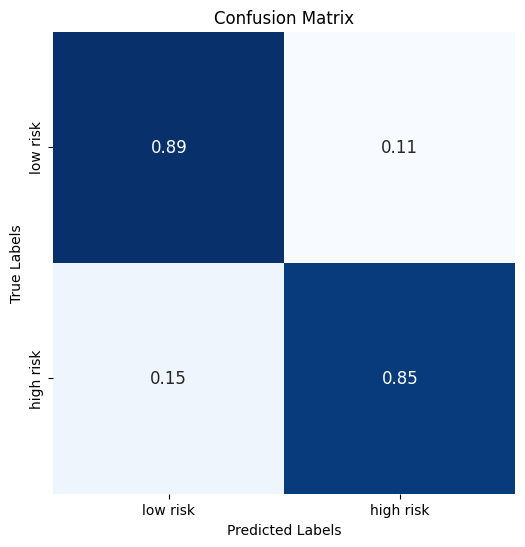

In [51]:
plot_confusion_matrix(y, y_pred_binary, risk_classes, normalize=True)